# Implementación de Quantum Circuit Learning para regresión de una función
(siguiendo el tutorial de QuLacs en https://docs.qulacs.org/en/latest/apply/5.2_qcl.html)

Ajuste de una función coseno:  $y=\cos(\pi x)$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from qulacs import QuantumState, QuantumCircuit
from qulacsvis import circuit_drawer
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
## seed of random number
random_seed = 0
## initialization of random number generator
np.random.seed(random_seed)

Suponemos que tenemos datos experimentales ruidosos y buscamos realizar un ajuste utilizando una función coseno. 

En este caso, generamos dichos datos "artificialmente" tomando 200 puntos al azar en el intervalo [-1,1] y aplicando ruido gaussiano sobre los mismos.

Separamos 100 datos para entrenamiento y 100 para testeo.

In [3]:
## Función que se busca aprender
func_to_learn = lambda x: np.cos(x*np.pi)

## Intervalo y número de datos total.
x_min = - 1.; x_max = 1.
num_x_data = 200

## Preparamos artificialmente los datos de entrenamiento
x_data = x_min + (x_max - x_min) * np.random.rand(num_x_data)
y_data = func_to_learn(x_data)

## Se agrega ruido para simular datos experimentales
mag_noise = 0.1
y_data = y_data + mag_noise * np.random.randn(num_x_data)

#Separo en conjuntos de entrenamiento y validación
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.5, random_state=0)
x_train, x_test, y_train,y_test = np.array(x_train), np.array(x_test), np.array(y_train), np.array(y_test)

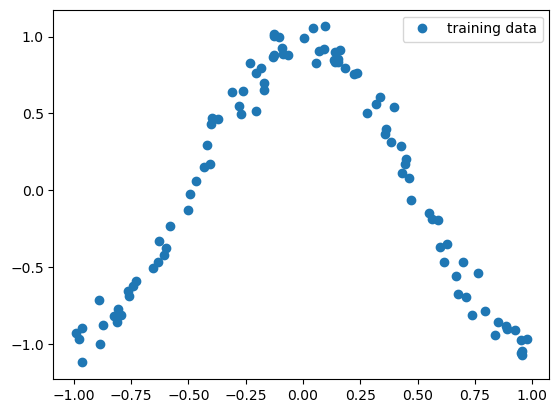

In [4]:
plt.plot(x_train, y_train, "o", label = 'training data'); plt.legend(); plt.show()

# Simulación de un circuito cuántico

Simularemos un circuito cuántico que "aprenda" a reproducir estos datos. Utilizaremos un sistema de 4 qubits y 3 capas. 

In [5]:
########  Parameter  #############
nqubit = 4 ## number of qubit
c_depth = 3 ## depth of circuit

### Librería qulacs

Para simular los comportamientos de sistemas cuánticos se utiliza la librería qulacs. 

Por ejemplo, en las siguientes líneas importamos las matrices de Pauli X y Z que son compuertas que actúan en un solo qubit.

In [6]:
## Basic gate
from qulacs.gate import X, Z
I_mat = np.eye(2, dtype=complex)
X_mat = X(0).get_matrix() # applied to qubit 0
Z_mat = Z(0).get_matrix() # applied to qubit 0

Definimos la función ```make_fullgate```  para crear operadores aplicables al sistema completo a partir de operadores o compuertas que actúan en un único spin o qubit. 

Estas funciones toman dos argumentos: ```list_SiteAndOperator``` y ```nqubit```.

```list_SiteAndOperator``` es una lista de listas, cada una de las cuales contiene un sitio y el operador que actúa en ese sitio.

```nqubit``` es el número de componentes del sistema. 

In [7]:
def make_fullgate(list_SiteAndOperator, nqubit):
    '''
    Toma list_SiteAndOperator = [ [i_0, O_0], [i_1, O_1], ...],
    Inserta una identidad si no hay operador actuando en algún sitio
    Genera matriz de tamaño: (2**nqubit, 2**nqubit):
    I(0) * ... * O_0(i_0) * ... * O_1(i_1) ...
    '''
    list_Site = [SiteAndOperator[0] for SiteAndOperator in list_SiteAndOperator]
    list_SingleGates = [] ## Producto tensorial de compuertas de 1 qb
    cnt = 0
    for i in range(nqubit):
        if (i in list_Site):
            list_SingleGates.append( list_SiteAndOperator[cnt][1] )
            cnt += 1
        else: 
            list_SingleGates.append(I_mat)

    return reduce(np.kron, list_SingleGates)

## Codificación de input en estado cuántico

Es necesario codificar el conjunto ${x_i}$ de números reales, es decir, nuestras variables de entrada.

Para eso, creamos la compuerta $U_{in}(x_i)$ que transformará los estados $\vert{00...0}\rangle$ usando compuertas de rotación. 

Siguiendo el trabajo de referencia, definimos:

$U_{in}(x_{i}) \ =\ \prod _{j} R_{j}^{Z}\left(\cos^{-1} x_{i}^{2}\right) R_{j}^{Y}\left(\sin^{-1} x_{i}\right)$

De esta forma el input $x_i$, se codifica según: $\vert{\psi_{in}(x_i)}\rangle = U_{in}(x_i)\vert{00...0}\rangle$

In [8]:
# Función para codificar una variable real en un estado cuántico
def U_in(x):
    U = QuantumCircuit(nqubit)

    angle_y = np.arcsin(x)
    angle_z = np.arccos(x**2)

    for i in range(nqubit):
        U.add_RY_gate(i, angle_y)
        U.add_RZ_gate(i, angle_z)

    return U

En el siguiente ejemplo, podemos ver cómo codificamos el valor $x=0.1$ en un estado inicializado como $\vert{0000}\rangle$

In [9]:
state = QuantumState(nqubit) # Estado Inicial |0000>
state.set_zero_state()
print(state.get_vector())

[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]


In [10]:
# Codificación de x en el estado cuántico
x = 0.1 
U_in(x).update_quantum_state(state) # Calculamos U_in|0000>
print( [f"{num:.2E}" for num in state.get_vector()])

['-9.95E-01+1.99E-02j', '-4.99E-04-4.99E-02j', '-4.99E-04-4.99E-02j', '2.50E-03-2.17E-19j', '-4.99E-04-4.99E-02j', '2.50E-03+2.17E-19j', '2.50E-03+2.17E-19j', '-1.25E-06+1.25E-04j', '-4.99E-04-4.99E-02j', '2.50E-03+0.00E+00j', '2.50E-03+0.00E+00j', '-1.25E-06+1.25E-04j', '2.50E-03+0.00E+00j', '-1.25E-06+1.25E-04j', '-1.25E-06+1.25E-04j', '-6.28E-06-1.26E-07j']


La librería qulacs_viz nos permite visualizar la compuerta de entrada obtenida

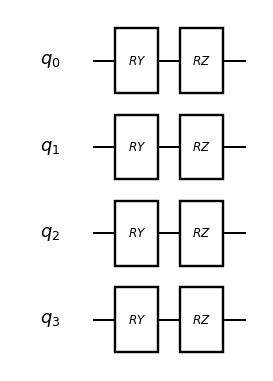

In [11]:
circuit_drawer(U_in(x),'mpl')

## Circuito Cuántico Parametrizado

A continuación, generamos el circuito cuántico que vamos a optimizar. 

El mismo consiste de 3 capas. En cada una, aplicaremos:
- una compuerta de Haddammard a cada qubit
- $N_{qubits} - 1$ compuertas CNOT 
- tres compuertas de rotación parametrizadas según: $U_{rot}(\theta_j^{(i)}) = R^X_j(\theta^{(i)}_{j1})R^Z_j(\theta^{(i)}_{j2})R^X_j(\theta^{(i)}_{j3})$

En total se tienen $3 \times N_{qubits} \times d$ parametros. 

Los valores iniciales para $\theta$ se eligen aleatoriamente de una distribución uniforme en $\left[ 0,2 \pi \right]$ 

La clase ```ParametricQuantumCircuit``` de qulacs permite crear un circuito cuántico con compuertas que dependen de parámetros que pueden ser actualizados. 

In [12]:
from qulacs import ParametricQuantumCircuit

U_out = ParametricQuantumCircuit(nqubit)

In [13]:
for d in range(c_depth):

    for i in range(nqubit):
        U_out.add_H_gate(i)
        if i > 0:
            U_out.add_CNOT_gate(i, i - 1)  # control, objetivo

    for i in range(nqubit):
        angle = 2.0 * np.pi * np.random.rand()
        U_out.add_parametric_RX_gate(i, angle)

        angle = 2.0 * np.pi * np.random.rand()
        U_out.add_parametric_RZ_gate(i, angle)

        angle = 2.0 * np.pi * np.random.rand()
        U_out.add_parametric_RX_gate(i, angle)

Usando qulacs_viz nuevamente podemos ver el circuito resultante.

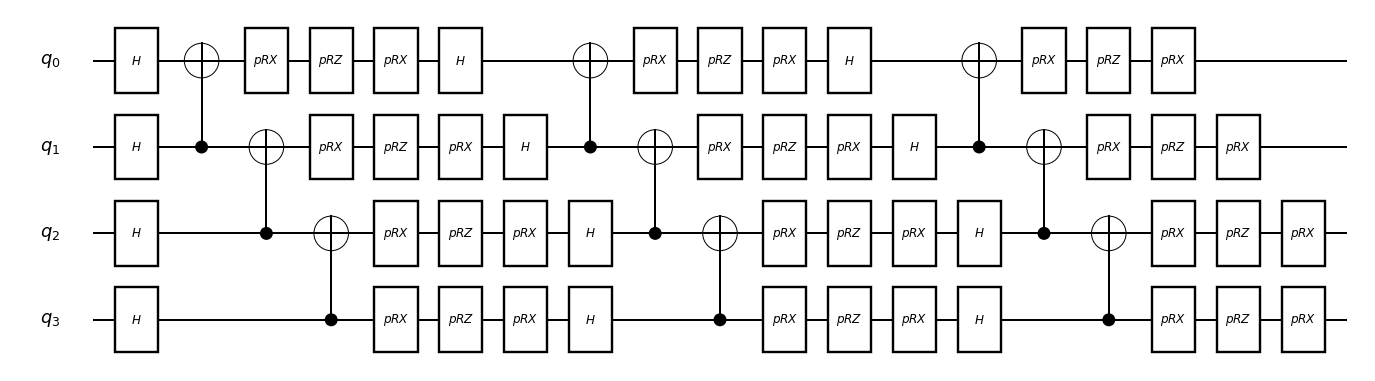

In [14]:
circuit_drawer(U_out,'mpl')

Es posible acceder a los parámetros del circuito definido

In [15]:
# Acceder a valores de los parámetros
parameter_count = U_out.get_parameter_count()
theta_init = [U_out.get_parameter(ind) for ind in range(parameter_count)]
print('Initial parameters:', theta_init)

Initial parameters: [2.8229826856732885, 1.9130314237335426, 5.272780762920498, 1.493775948123507, 3.156606057778451, 5.922427424410481, 3.9835250192549365, 5.449340049474277, 5.907511705821757, 4.717194749351038, 4.395559739673432, 6.081907025943442, 6.2480044309620775, 2.838879358015791, 0.4452879490100944, 1.839679156376946, 0.9572728482568181, 2.6231442560659715, 0.8249151796526367, 3.7957841100296026, 2.405253972770563, 5.625875432415682, 6.080833262211037, 3.436179178887666, 1.7267674162587254, 3.7210934656291865, 5.63451653340496, 2.555580982495167, 3.4688101165240175, 1.7068446780776063, 2.861639988065313, 2.524040583192261, 1.5608278339148927, 3.1784522302472467, 1.950180245426615, 2.3438471758012493]


Luego, definimos una función  ```set_U_out``` que permite actualizar $\theta$ en $U(\theta)$ 

In [16]:
# Function that updates parameter theta
def set_U_out(theta):
    global U_out

    parameter_count = U_out.get_parameter_count()

    for i in range(parameter_count):
        U_out.set_parameter(i, theta[i])

## Medida

Se toma como output del modelo el valor de expectación de la magnetización del primer qubit para el estado de salida $\vert{\psi_{out}}\rangle$, es decir:

$y(\theta,x_i)=\left<\psi_\text{out}|Z_0|\psi_\text{out}\right> $

In [17]:
# Create observable Z_0
from qulacs import Observable

obs = Observable(nqubit)
obs.add_operator(2.,'Z 0')

### Repaso

Hasta ahora tenemos:
- Datos Etiquetados de entrenamiento y su compuerta de codificación
- Circuito Parametrizado inicializado al azar
- Operadores de medición definidos

$\to$ Ya podemos empezar la optimización!

### Cálculo de $y(\theta \ , x_i)$

Definimos la función ```qcl_pred``` para calcular para cada entrada las predicciones provistas por $U_{out}$ para cada conjunto de parámetros ($\mathbf{\theta}$). 
1. Inicializamos el estado en $\vert{0000}\rangle$
2. Codificamos el valor $x$ de la entrada usando $U_{in}$
3. Aplicamos el circuito parametrizado $U_{out}$
4. Medimos usando la función ```get_output```

In [18]:
# Función que predice el valor y(x_i,theta) del modelo a partir del input x_i
def qcl_pred(x, U_out):
    state = QuantumState(nqubit)
    state.set_zero_state()

    # Calculate input state
    U_in(x).update_quantum_state(state)

    # Calculate output state
    U_out.update_quantum_state(state)

    # Output of the model
    res = obs.get_expectation_value(state)

    return res

### Función costo
Utilizamos como función costo el error cuadrático medio. Esta será la función que minimizaremos 

In [19]:
# Cálculo de función costo
def cost_func(theta):
    '''
    theta: ndarray of length c_depth * nqubit * 3
    '''
    
    # actualizar el parámetros theta de U_out
    # U_out es una variable global
    
    set_U_out(theta)

    # calcular predicciones para el conjunto de entrenamiento
    y_pred = [qcl_pred(x, U_out) for x in x_train]

    # Error cuadrático medio 
    L = ((y_pred - y_train)**2).mean()

    return L

# Resultados

Minimizamos usando el método de Nelder-Mead a través de la función minimize de scipy.

In [20]:
from scipy.optimize import minimize
result = minimize(cost_func, theta_init, method='Nelder-Mead')


In [21]:
# Función costo luego de optimizar
result.fun

0.010167666035512446

In [22]:
# Parámetros optimizados
theta_opt = result.x
print(theta_opt)

[ 4.306457    1.60951104  5.47731161  0.90950182  4.25608303  4.662585
  4.18020814  6.73266101 -0.12697024  7.62373569  7.78051085  2.89571985
  4.63725617  3.67306924  0.42649471  1.3220854   1.18183488  6.42246288
  0.78903614  5.66061447  5.45426927  7.83009887  7.61922962  0.37613153
 -0.12852338  5.45174952  3.31934841 -0.90845323  3.91772523  1.36751272
  2.9859641   4.26104515  0.92549582  1.49146691  1.63724936  0.70119443]


### Predicción del modelo sobre los datos de entrenamiento

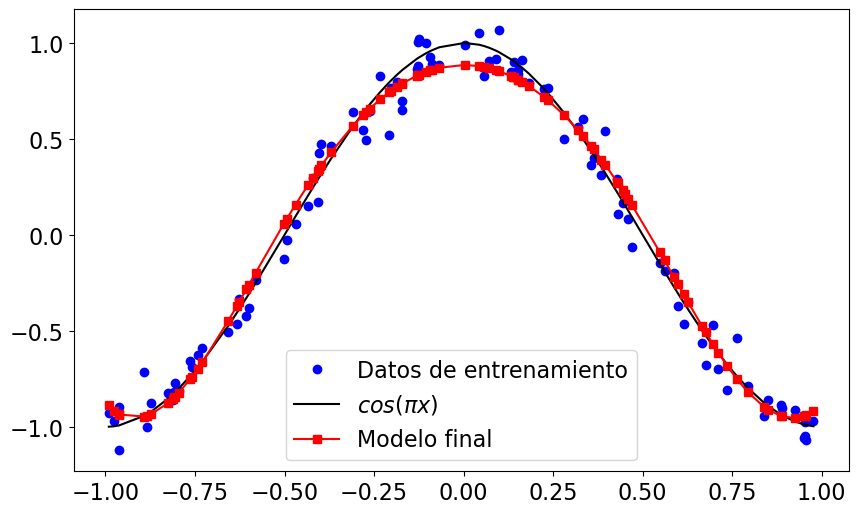

In [39]:
plt.rcParams.update({'font.size': 16})  # Set the default font size to 12
# Insert optimized theta into U_out
set_U_out(theta_opt)
# teacher data
plt.figure(figsize=(10, 6)); plt.plot(x_train, y_train, "o", label='Datos de entrenamiento', color = 'blue')
# Prediction of the model
plt.plot(np.sort(x_train),np.cos(np.pi*np.sort(x_train)), label='$cos(\pi x)$', color = 'black')
y_pred = np.array([qcl_pred(x, U_out) for x in np.sort(x_train)])
plt.plot(np.sort(x_train), y_pred,'-s', label='Modelo final', color = 'red');plt.legend() ; plt.show()

## Testeo

Podemos graficar también el resultado para el conjunto de testeo

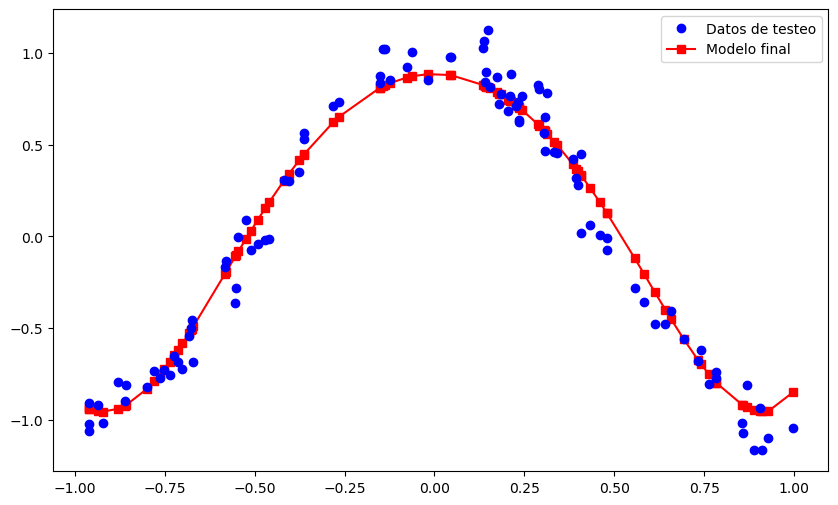

In [32]:
# teacher data
plt.figure(figsize=(10, 6)); plt.plot(x_test, y_test, "o", label='Datos de testeo', color = 'blue')
# Prediction of the model
y_pred = np.array([qcl_pred(x, U_out) for x in np.sort(x_test)])
plt.plot(np.sort(x_test), y_pred,  '-s', label='Modelo final', color = 'red', zorder = -2)
plt.legend()
plt.show()

Calculamos distintas métricas sobre el conjunto de testeo para chequear la precisión del método utilizado. Además, usando scikit-learn, implementamos un perceptrón multicapa para comparar.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = np.array([qcl_pred(x, U_out) for x in x_test])
# Métricas para QCL
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r_squared = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

In [35]:
from sklearn.neural_network import MLPRegressor
# Perceptrón multicapa (MLP)
model = MLPRegressor(hidden_layer_sizes=(12,12,12), activation='relu', solver='adam', max_iter=1000, random_state=0)

x_train_rs = x_train.reshape(-1, 1)
x_test_rs = x_test.reshape(-1, 1)
# Entrenamiento 
model.fit(x_train_rs, y_train)
#Prediccion
y_pred_mlp = model.predict(x_test_rs)
# Métricas para MLP
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
r_squared_mlp = r2_score(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)

In [43]:
metrics = {
    'Metric': ['Mean Squared Error (MSE)', 'Mean Absolute Error (MAE)', 'R-squared'],
    'QCL': [
        f'{mse:.4f} ({(100*mse):.2f} %)'.format(mse, 100 * (mse)),
        f'{mae:.4f} ({(100*mae):.2f} %)'.format(mae, 100 * (mae)),
        f'{r_squared:.4f}'.format(r_squared),
    ],
    'MLP': [
        f'{mse_mlp:.4f} ({(100*mse_mlp):.2f} %)'.format(mse_mlp, 100 * (mse_mlp)),
        f'{mae_mlp:.4f} ({(100*mae_mlp):.2f} %)'.format(mae_mlp, 100 * (mae_mlp)),
        f'{r_squared_mlp:.4f}'.format(r_squared_mlp),
    ]
}

# Create a DataFrame to compare results
comparison_df = pd.DataFrame(metrics)

# Print the comparison table in markdown format
print(comparison_df.to_markdown(index=False))

| Metric                    | QCL             | MLP              |
|:--------------------------|:----------------|:-----------------|
| Mean Squared Error (MSE)  | 0.0149 (1.49 %) | 0.0177 (1.77 %)  |
| Mean Absolute Error (MAE) | 0.0971 (9.71 %) | 0.1065 (10.65 %) |
| R-squared                 | 0.9712          | 0.9657           |
